# Synthetic data: sizes, labels, diversity, overlap with real data

Our generated MISC sets (`synth.*`). They are kept apart from the real-data catalogue
(`datasets_eda.ipynb`, `docs/DATASETS.md`) because they change with every synthesis campaign.
The static summary is [`docs/SYNTHETIC_DATA.md`](../docs/SYNTHETIC_DATA.md). Rerun after any new
generation:

`jupyter nbconvert --to notebook --execute --inplace notebooks/synthetic_eda.ipynb`

**Role:** training augmentation only, never gold.

In [1]:
import os, sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src')); os.chdir(ROOT)
warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from eda import registry, overlap, stats
from synth import metrics as SM
pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', font_scale=0.9)
ALL = registry.load_all(include_synth=True)
SYN = registry.SYNTH_IDS
REAL = registry.REAL_IDS
print({k: len(ALL[k]) for k in SYN})

{'synth.v1': 2631, 'synth.v2_proto': 716, 'synth.v2_boundary': 645, 'synth.v3_hlqcmix': 848, 'synth.v3_mivmix': 788}


## 1. Names and lineage
Every `data/synth/aug` file is **the 1,925 HLQC train rows + the synthetic rows** (`conv_id` starts `synth:`).
The loader returns the synthetic rows only. `*_proto_eval.csv` is **training** data; "eval" refers to the MIV6.3A topic mix.

In [2]:
pd.DataFrame([{'id': m.id, 'file': f, 'lineage': m.lineage, 'known issues': '; '.join(m.known_issues)}
              for m in registry.META.values() if m.id in SYN for f in m.files])

,id,file,lineage,known issues
0,synth.v1,data/synth/aug/Qwen2_5-32B-Instruct-AWQ.csv,"prompts_v1, code-conditioned single shots",mode collapse (Self-BLEU 0.199)
1,synth.v2_proto,data/synth/aug/Qwen2_5-32B-Instruct-AWQ_proto.csv,"prompts_v2 ontology windows, prototype focus",
2,synth.v2_boundary,data/synth/aug/Qwen2_5-32B-Instruct-AWQ_boundary.csv,"prompts_v2, confusable-pair focus",
3,synth.v3_hlqcmix,data/synth/aug/Qwen2_5-32B-Instruct-AWQ_proto_train.csv,generate.py v3 --mix train (HLQC topic proportions); file name says 'proto_train',
4,synth.v3_mivmix,data/synth/aug/Qwen2_5-32B-Instruct-AWQ_proto_eval.csv,generate.py v3 --mix eval: topic proportions measured on the MIV6.3A TEST set; file name says 'proto_eval' but it is...,uses test-set topic statistics (documented ablation)


## 2. Size and label coverage

In [3]:
rows = []
for s in SYN:
    d = ALL[s]; lab = d[d.t2.notna()]
    rows.append({'id': s, 'windows': d.conv_id.nunique(), 'units': len(d), 'labelled units': len(lab),
                 'counsellor codes': lab[lab.speaker == 'counsellor'].t2.nunique(),
                 'client codes': lab[lab.speaker == 'client'].t2.nunique(),
                 'RCP': int((lab.t2 == 'RCP').sum()), 'TS-': int((lab.t2 == 'TS-').sum()),
                 'AC+': int((lab.t2 == 'AC+').sum()), 'AC-': int((lab.t2 == 'AC-').sum())})
pd.DataFrame(rows).set_index('id')

,windows,units,labelled units,counsellor codes,client codes,RCP,TS-,AC+,AC-
id,,,,,,,,,
synth.v1,862,2631,862,18,16,8,20,20,79
synth.v2_proto,50,716,352,12,14,0,0,20,2
synth.v2_boundary,48,645,292,12,14,0,0,17,7
synth.v3_hlqcmix,50,848,409,14,15,0,0,18,4
synth.v3_mivmix,50,788,387,16,16,0,5,14,9


In [4]:
H = registry.handbook_check({k: ALL[k] for k in SYN + ['misc.hlqc.gold', 'misc.miv63a.gold']})
H = H[H.scheme == 'MISC 2.5']
H['real gold'] = H.datasets_with_examples.str.contains('misc.')
H['synthetic'] = H.datasets_with_examples.str.contains('synth')
print('MISC 2.5 classes covered ONLY by synthetic data:')
H[H.synthetic & ~H['real gold']][['speaker', 'code', 'datasets_with_examples']]

MISC 2.5 classes covered ONLY by synthetic data:


,speaker,code,datasets_with_examples
11,counsellor,RCP,synth.v1
31,client,TS-,"synth.v1, synth.v3_mivmix"


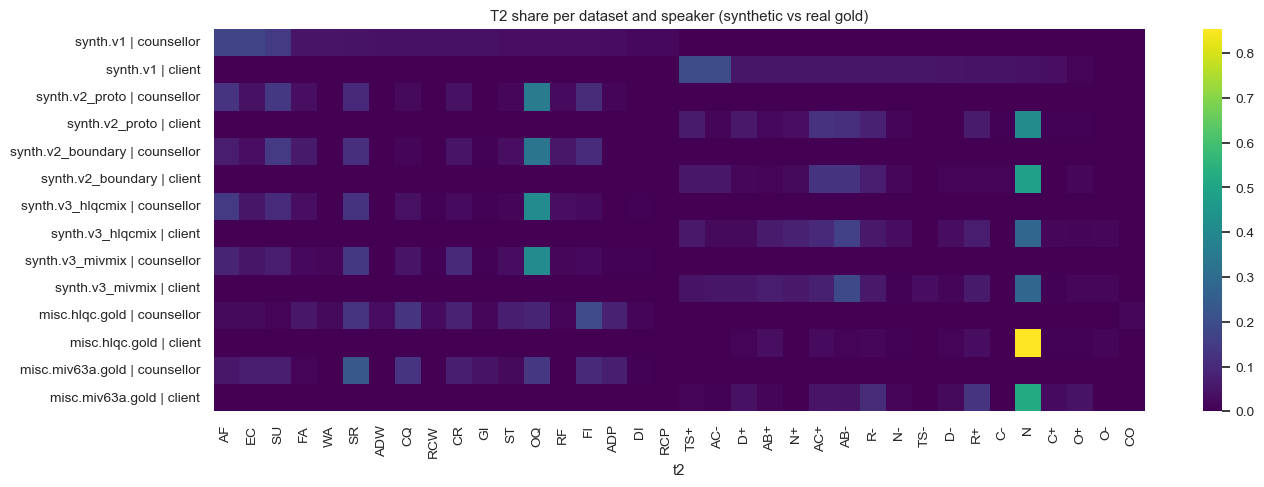

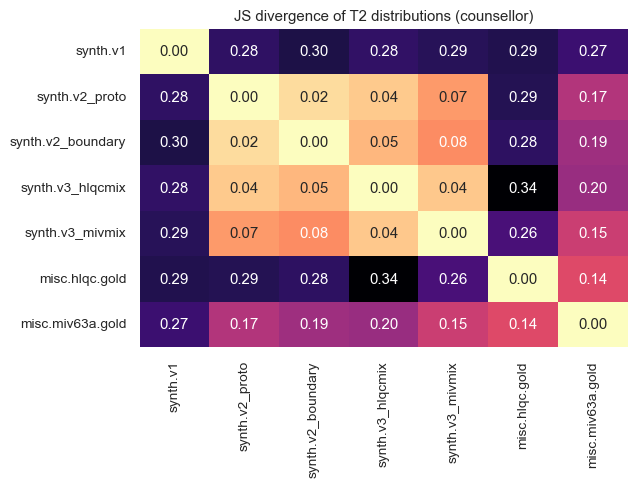

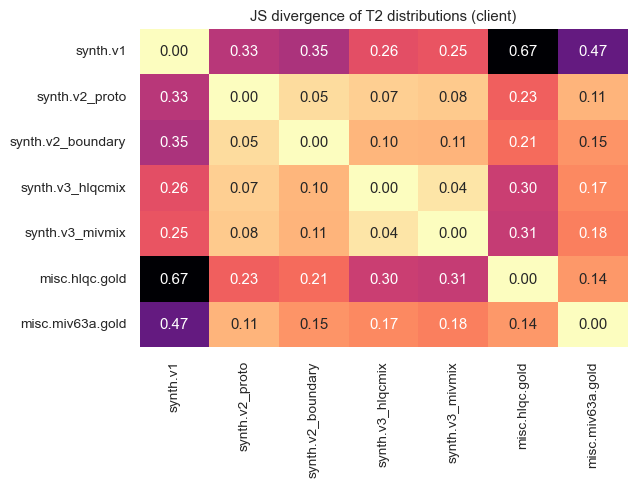

In [5]:
rows = []
for s in SYN + ['misc.hlqc.gold', 'misc.miv63a.gold']:
    for spk in ['counsellor', 'client']:
        d = ALL[s][(ALL[s].speaker == spk) & ALL[s].t2.notna()].t2.value_counts(normalize=True)
        rows.append(d.rename(f'{s} | {spk}'))
dist = pd.DataFrame(rows).fillna(0)
plt.figure(figsize=(14, 5)); sns.heatmap(dist, cmap='viridis'); plt.title('T2 share per dataset and speaker (synthetic vs real gold)')
plt.tight_layout(); plt.show()
for spk in ['counsellor', 'client']:
    J = stats.js_matrix({k: ALL[k] for k in SYN + ['misc.hlqc.gold', 'misc.miv63a.gold']}, spk, 't2')
    plt.figure(figsize=(6.5, 5)); sns.heatmap(J, annot=True, fmt='.2f', cmap='magma_r', cbar=False)
    plt.title(f'JS divergence of T2 distributions ({spk})'); plt.tight_layout(); plt.show()

## 3. Diversity (`synth.metrics`, against HLQC gold text)

In [6]:
real = ALL['misc.hlqc.gold'].text.tolist()
card = pd.DataFrame({s: SM.scorecard(ALL[s].text.tolist(), real) for s in SYN}).T
card[['n', 'distinct_1', 'distinct_2', 'self_bleu', 'self_near_dup_%']].round(3)

,n,distinct_1,distinct_2,self_bleu,self_near_dup_%
synth.v1,2631.0,0.032,0.193,0.263,30.749
synth.v2_proto,716.0,0.128,0.549,0.047,8.799
synth.v2_boundary,645.0,0.129,0.543,0.046,7.752
synth.v3_hlqcmix,848.0,0.104,0.485,0.037,6.014
synth.v3_mivmix,788.0,0.105,0.464,0.066,8.756


## 4. Overlap with real data and with each other
Same detector as the real-data notebook (5-gram containment), with all datasets indexed together.

In [7]:
display(overlap.known_relations(ALL, synth=True))
P = overlap.pairwise(ALL)
dup = P[(P.containment >= 0.10) & (P.conv_a != P.conv_b)]
is_s = lambda c: c.str.startswith('synth')
print('Synthetic windows sharing text with real sessions (copied HLQC exemplar phrases):')
display(dup[is_s(dup.dataset_a) ^ is_s(dup.dataset_b)][['dataset_a','conv_a','dataset_b','conv_b','shared_shingles','containment']])
print('Synthetic-synthetic duplicates:')
display(dup[is_s(dup.dataset_a) & is_s(dup.dataset_b)][['dataset_a','conv_a','dataset_b','conv_b','containment']])
print('Any synthetic window overlapping the MIV6.3A test set:',
      int(((dup.dataset_a == 'misc.miv63a.gold') | (dup.dataset_b == 'misc.miv63a.gold')).sum()))

,dataset_a,dataset_b,relation,detail,verified
0,synth.*,misc.hlqc.gold,derived,"every data/synth/aug file = the 1,925 HLQC gold rows + synthetic rows; synthesis exemplars are HLQC gold",
1,synth.v3_mivmix,misc.miv63a.gold,derived,"topic mix measured on the MIV6.3A test set (statistics only, no text)",


Synthetic windows sharing text with real sessions (copied HLQC exemplar phrases):


,dataset_a,conv_a,dataset_b,conv_b,shared_shingles,containment
444,misc.hlqc.gold,low_033,synth.v3_hlqcmix,synth:proto:train:47,24,0.203
445,pool.hlqc,low_033,synth.v3_hlqcmix,synth:proto:train:47,24,0.203
488,annomi.gold,44,synth.v3_hlqcmix,synth:proto:train:47,18,0.153
495,misc.hlqc.gold,high_099,synth.v3_mivmix,synth:proto:eval:21,22,0.142
496,pool.hlqc,high_099,synth.v3_mivmix,synth:proto:eval:21,22,0.142
511,misc.hlqc.gold,high_121,synth.v2_proto,synth:proto:48,16,0.125
512,pool.hlqc,high_121,synth.v2_proto,synth:proto:48,16,0.125
515,misc.hlqc.gold,high_121,synth.v3_mivmix,synth:proto:eval:21,19,0.123
516,miti.casaa.gold,casaa_emmys-first-encounter,synth.v3_mivmix,synth:proto:eval:21,19,0.123
517,pool.hlqc,high_121,synth.v3_mivmix,synth:proto:eval:21,19,0.123


Synthetic-synthetic duplicates:


,dataset_a,conv_a,dataset_b,conv_b,containment
40,synth.v3_hlqcmix,synth:proto:train:19,synth.v3_mivmix,synth:proto:eval:19,0.913
44,synth.v3_hlqcmix,synth:proto:train:33,synth.v3_mivmix,synth:proto:eval:33,0.905
153,synth.v1,synth:counsellor:EC:1,synth.v1,synth:counsellor:EC:12,0.605
164,synth.v1,synth:client:TS+:38,synth.v1,synth:client:TS+:61,0.583
174,synth.v1,synth:counsellor:FA:18,synth.v1,synth:counsellor:FA:9,0.533
197,synth.v1,synth:client:TS+:38,synth.v1,synth:client:TS+:6,0.487
218,synth.v1,synth:client:TS+:52,synth.v1,synth:client:TS+:53,0.469
272,synth.v1,synth:counsellor:CR:14,synth.v1,synth:counsellor:SU:10,0.390
293,synth.v1,synth:client:AC-:13,synth.v1,synth:client:AC-:55,0.372
295,synth.v1,synth:counsellor:GI:14,synth.v1,synth:counsellor:GI:37,0.367


Any synthetic window overlapping the MIV6.3A test set: 0


## 5. Split manifest (`data/splits/synthetic.json`)

In [8]:
print(json.dumps(json.load(open('data/splits/synthetic.json')), indent=1))

{
 "dup_threshold": 0.1,
 "redundant_duplicates": {
  "synth.v1": [
   "synth:client:TS+:61",
   "synth:counsellor:EC:12",
   "synth:counsellor:FA:9"
  ],
  "synth.v2_boundary": [],
  "synth.v2_proto": [],
  "synth.v3_hlqcmix": [],
  "synth.v3_mivmix": []
 },
 "role": "train only; never gold",
 "seed": 42,
 "v3_windows_shared_by_both_mixes": [
  "synth:proto:train:19 = synth:proto:eval:19",
  "synth:proto:train:33 = synth:proto:eval:33"
 ]
}


## 6. Checks

In [9]:
assert all(not ALL[s].conv_id.str.startswith('synth').eq(False).any() for s in SYN), 'real rows leaked into a synth loader'
assert int(((dup.dataset_a == 'misc.miv63a.gold') | (dup.dataset_b == 'misc.miv63a.gold')).sum()) == 0
print('all checks passed')

all checks passed
